In [11]:
import joblib 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick which model to explain — comment out the others
#TAG = "augmented"
#TAG = "freegen_qwen"
#TAG = "freegen_llama"
#TAG = "rewrite_qwen"
TAG = "rewrite_llama"

b = joblib.load(f"xgb_bundle_{TAG}.joblib")
clf, tfidf         = b["clf"], b["tfidf"]
feat_names, hand_names = b["feat_names"], b["hand_names"]
Xte, te_x, te_y    = b["Xte"], b["te_x"], np.array(b["te_y"])
hte, htr, tr_y     = b["hte"], b["htr"], np.array(b["tr_y"])
prob, pred         = np.array(b["prob"]), np.array(b["pred"])
print(f"Loaded {TAG}: {Xte.shape[0]} test notes, {len(feat_names)} features")

Loaded rewrite_llama: 400 test notes, 513 features


# Q3: Why was this individual note flagged?


SYNTHETIC note  (P_synthetic=0.999, true=1)
Discharge Summary for <PHI>

Unit Number: <PHI>

Admitted On: <PHI> 
Discharged On: <PHI>
Date of Birth: <PHI>
Sex: Male

Patient Allergies:

* Aspirin
* Ciprofloxacin
* Beta-blockers (beta-adrenergic blocking agents)
* Nonsteroidal anti-inflammatory drugs (NSAIDs)

Attending Physician: <PHI>

Chief Complaint: The patient presented with symptoms suggestive of altered mental status.

Major Surgical or Invasive Procedures Performed: Nil.

History of Present Illness:
The patient, <PHI>, has a compl ...



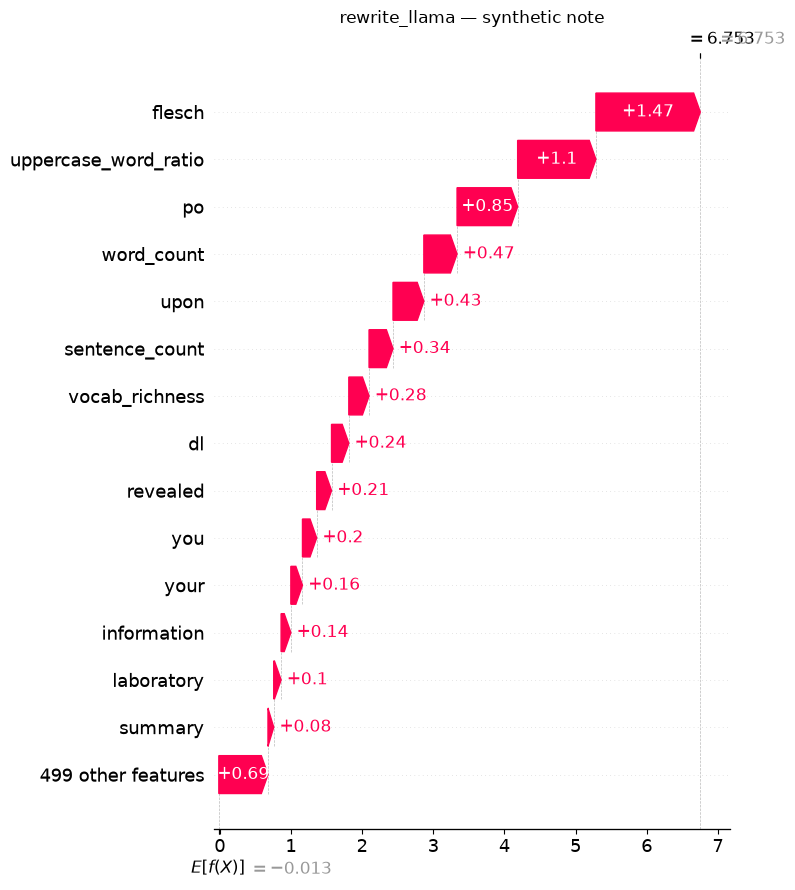


REAL note  (P_synthetic=0.001, true=0)
Name: <PHI> Unit No: <PHI>
Admission Date: <PHI> Discharge Date: <PHI>
Date of Birth: <PHI> Sex: M
Service: MEDICINE
Allergies: Patient recorded as having No Known Allergies to Drugs
Attending: <PHI>.
Chief Complaint: toe erythema
Major Surgical or Invasive Procedure: None
History of Present Illness:
Mr. <PHI> is a <PHI> year old man with history of DM and ESRD on peritoneal dialysis who presented with increased right toe redness over <PHI> days.
The redness was not accompanied by any pain, but  ...



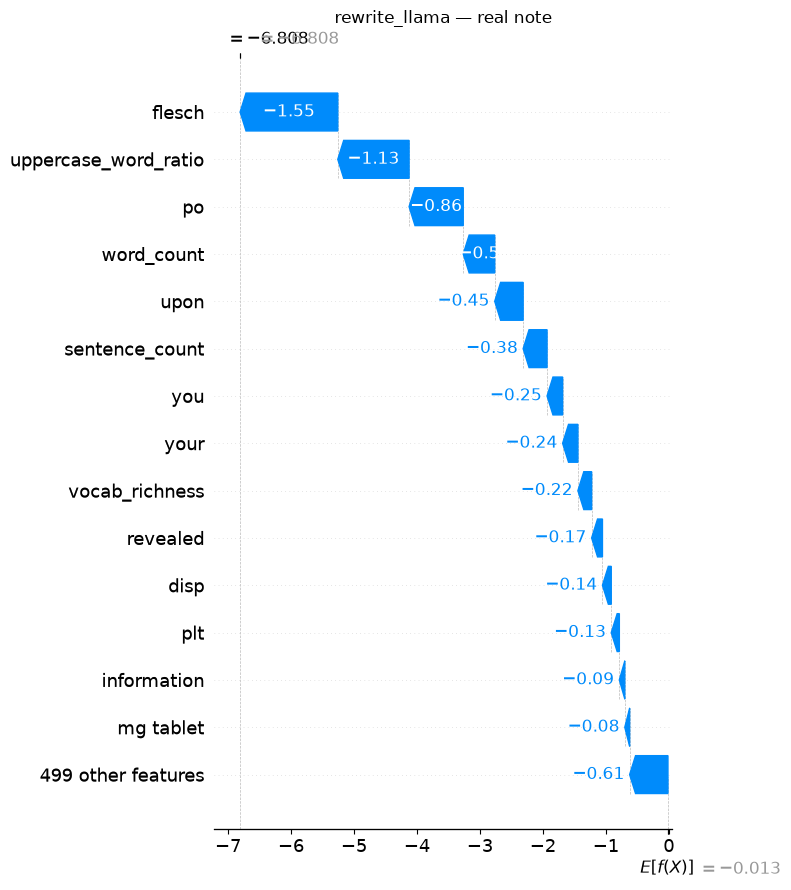

In [12]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(Xte)
base = explainer.expected_value

# a confidently-caught synthetic note, and a confidently-correct real note
syn_candidates  = np.where((te_y == 1) & (pred == 1))[0]
real_candidates = np.where((te_y == 0) & (pred == 0))[0]
syn_i  = int(syn_candidates[np.argmax(prob[syn_candidates])])
real_i = int(real_candidates[np.argmin(prob[real_candidates])])

for label, i in [("synthetic", syn_i), ("real", real_i)]:
    print(f"\n{'='*60}\n{label.upper()} note  (P_synthetic={prob[i]:.3f}, true={te_y[i]})\n{'='*60}")
    print(str(te_x[i])[:500], "...\n")
    shap.plots._waterfall.waterfall_legacy(
        base, shap_values[i], feature_names=feat_names, max_display=15, show=False)
    plt.title(f"{TAG} — {label} note"); plt.tight_layout()
    plt.savefig(f"q3_waterfall_{TAG}_{label}.png", dpi=150, bbox_inches="tight"); plt.show()